# Fire &amp; Smoke Detection — 02 · Evaluation, Testing and Demo

**Object Detection Final Project — DOTPY Academy**
Majid · YOLO11n · Transfer learning from COCO

---

### What this notebook does

Loads the two sets of weights trained in notebook 01, decides between them on the
**held-out test split**, calibrates confidence thresholds on labelled data, tests
on unseen and external images, and runs the video demo.

**It never retrains.** Run time is a few minutes.

### Why the work is split across two notebooks

Notebook 01 takes about four hours of GPU time. Re-running it every time a metric
needs checking wastes that time and produces a *different* set of weights each
run, which makes the numbers impossible to attribute. Weights are trained once,
saved to Drive, and everything downstream loads them.

### The provenance problem this notebook solves

During the project, weights were downloaded and re-uploaded several times and
ended up named `best.pt`, `best (1).pt` and `best (1) (1).pt`. At that point it
was no longer possible to say which training run produced which exported file —
and therefore which run the reported metrics belonged to.

Every step below records a **SHA-256 hash** of the file it operated on and writes
it into a manifest. Metrics, exported model and thresholds are tied to one hash,
so the question *"which model produced this number?"* has an answer.

## 1 · Environment

In [ ]:
# تثبيت مكتبة Ultralytics الرسمية لـ YOLO
!pip install ultralytics roboflow

import os
from ultralytics import YOLO

# التأكد من التوصيل بالـ GPU
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics

## 2 · Dataset

Downloaded again because the test split is needed for evaluation, threshold
calibration and unseen-image testing. The images are identical to notebook 01.

In [ ]:
# Same public dataset as notebook 01 — needed here for the test split.
#   https://universe.roboflow.com/detection-projet/fire-smoke-detection-lk8z9
#   Licence: CC BY 4.0
# Put your key in Colab Secrets (key icon, left sidebar) named ROBOFLOW_KEY.
!pip install -q roboflow

from google.colab import userdata
from roboflow import Roboflow

rf      = Roboflow(api_key=userdata.get("ROBOFLOW_KEY"))
project = rf.workspace("detection-projet").project("fire-smoke-detection-lk8z9")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire--smoke-Detection-1 in yolov8:: 100%|██████████| 24266/24266 [00:07<00:00, 3290.27it/s]


## 3 · Drive, folders and GPU

Creates `weights/`, `exports/` and `reports/` under `MyDrive/YOLO11_Fire_Smoke/`.
The `.pt` files from notebook 01 were renamed to `run1_20ep.pt` and
`run2_v2_50ep.pt` — clear names instead of `best (1).pt`.

In [ ]:
import os, sys, json, hashlib, shutil, datetime, subprocess

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive'
except Exception as e:
    DRIVE = None
    print("Drive not mounted:", e)

PROJECT = f"{DRIVE}/YOLO11_Fire_Smoke" if DRIVE else "/content/YOLO11_Fire_Smoke"
os.makedirs(f"{PROJECT}/weights",  exist_ok=True)
os.makedirs(f"{PROJECT}/exports",  exist_ok=True)
os.makedirs(f"{PROJECT}/reports",  exist_ok=True)
print("project folder:", PROJECT)

try:
    import ultralytics
    print("ultralytics", ultralytics.__version__)
except ImportError:
    !pip install -q ultralytics
    import ultralytics; print("ultralytics", ultralytics.__version__)

import torch
print("torch", torch.__version__, "| CUDA", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
if not torch.cuda.is_available():
    print("  -> Runtime > Change runtime type > T4 GPU. val() on CPU takes minutes.")

Mounted at /content/drive
project folder: /content/drive/MyDrive/YOLO11_Fire_Smoke
ultralytics 8.4.121
torch 2.11.0+cu128 | CUDA True | Tesla T4


## 4 · Dataset composition

Confirms the class list and the real split sizes rather than relying on the
dataset page.

The result — 10,589 / 1,017 / 521 for a total of 12,127 — is worth comparing
against the 5,068 *source* images the publisher uploaded. The difference is
augmentation, and it is the origin of the leakage documented in the SRS: the
publisher applied augmentation **before** the split, so augmented copies of one
source frame end up on both sides of it.

In [ ]:
import os, glob
root = os.path.dirname(DATA_YAML)
print(open(DATA_YAML).read())
print("-" * 40)
tot = 0
for s in ('train', 'valid', 'test'):
    n = len(glob.glob(f"{root}/{s}/images/*"))
    tot += n
    print(f"{s:6s} {n:6d}")
print(f"{'TOTAL':6s} {tot:6d}")

names:
- fire
- smoke
nc: 2
roboflow:
  license: CC BY 4.0
  project: fire-smoke-detection-lk8z9
  url: https://universe.roboflow.com/detection-projet/fire-smoke-detection-lk8z9/dataset/1
  version: 1
  workspace: detection-projet
test: ../test/images
train: ../train/images
val: ../valid/images

----------------------------------------
train   10589
valid    1017
test      521
TOTAL   12127


## 5 · Evaluate on the held-out test split

Run this cell **twice** — once with `WEIGHTS` pointing at `run2_v2_50ep.pt`, then
again with `run1_20ep.pt` — so both runs are scored under identical conditions:
same Ultralytics version, same GPU, same 521 test images.

The SHA-256 printed at the top is what ties the metrics below to a specific file.

In [ ]:
# ================= الخلية C — تقييم الأوزان التي ستُصدَّر =================

WEIGHTS = f"{PROJECT}/weights/run1_20ep.pt"
DATA_YAML = "/content/Fire--smoke-Detection-1/data.yaml"
# =========================================================================

import os, glob, json, hashlib, datetime

def sha256(path, n=None):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    d = h.hexdigest()
    return d[:n] if n else d

assert os.path.exists(WEIGHTS),   f"not found: {WEIGHTS}"
assert os.path.exists(DATA_YAML), f"not found: {DATA_YAML} (run your cell 3 first)"

W_SHA   = sha256(WEIGHTS)
RUN_TAG = os.path.splitext(os.path.basename(WEIGHTS))[0]
print(f"weights : {WEIGHTS}")
print(f"size    : {os.path.getsize(WEIGHTS)/1e6:.2f} MB")
print(f"sha256  : {W_SHA}")
print(f"tag     : {RUN_TAG}\n")

from ultralytics import YOLO
model = YOLO(WEIGHTS)

metrics = model.val(data=DATA_YAML, split='test', imgsz=640,
                    project=f'/content/eval_{RUN_TAG}', name='test', exist_ok=True)

names = model.names
print("\n" + "=" * 62)
print(f"{'class':<10} {'P':>7} {'R':>7} {'mAP50':>8} {'mAP50-95':>10}")
print("-" * 62)
print(f"{'all':<10} {metrics.box.mp:>7.3f} {metrics.box.mr:>7.3f} "
      f"{metrics.box.map50:>8.3f} {metrics.box.map:>10.3f}")

per_class = {}
for i, c in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(i)
    print(f"{names[int(c)]:<10} {p:>7.3f} {r:>7.3f} {ap50:>8.3f} {ap:>10.3f}")
    per_class[names[int(c)]] = {'precision': float(p), 'recall': float(r),
                                'mAP50': float(ap50), 'mAP50_95': float(ap)}
print("=" * 62)

MANIFEST = {
    'run_tag':         RUN_TAG,
    'weights_path':    WEIGHTS,
    'weights_sha256':  W_SHA,
    'data_yaml':       DATA_YAML,
    'evaluated_split': 'test',
    'evaluated_at':    datetime.datetime.now().isoformat(timespec='seconds'),
    'ultralytics':     __import__('ultralytics').__version__,
    'metrics_all': {'precision': float(metrics.box.mp), 'recall': float(metrics.box.mr),
                    'mAP50': float(metrics.box.map50), 'mAP50_95': float(metrics.box.map)},
    'metrics_per_class': per_class,
}

print("\ncurves written for THIS model:")
for f in sorted(glob.glob(f'/content/eval_{RUN_TAG}/test/*.png')):
    print("  ", os.path.basename(f))

weights : /content/drive/MyDrive/YOLO11_Fire_Smoke/weights/run1_20ep.pt
size    : 5.47 MB
sha256  : ff6a0d6be0fa3882be8f163bb9bf2a404460d48e08eb11eaa0a899a00724fced
tag     : run1_20ep

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1166.8±464.0 MB/s, size: 29.8 KB)
val: Scanning /content/Fire--smoke-Detection-1/test/labels... 521 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 521/521 2.0Kit/s 0.3s
val: New cache created: /content/Fire--smoke-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 4.1it/s 8.1s
                   all        521        578      0.739      0.722       0.71      0.336
                  fire        445        479      0.869      0.889      0.914      0.482
                 smoke         99         9

### Result of the comparison

| Metric | run 1 — 20 epochs | run 2 — 50 epochs, AdamW |
|---|---|---|
| mAP@0.5 | **0.710** | 0.686 |
| mAP@0.5:0.95 | **0.336** | 0.333 |
| Precision | 0.739 | **0.763** |
| Recall | **0.722** | 0.651 |
| fire — mAP@0.5 | 0.914 | 0.912 |
| **smoke — recall** | **0.556** | 0.414 |
| smoke — mAP@0.5 | **0.507** | 0.460 |

**Run 1 wins, and the shorter run is the better one.**

Fire is unchanged between the two (0.914 vs 0.912) — thirty extra epochs, a
different optimiser and tuned augmentation added nothing to the strong class. The
entire loss landed on smoke: recall fell from 0.556 to 0.414, a 26% relative drop
in the class that matters most for early warning.

This is consistent with run 2's own training curves, where `val/dfl_loss` bottomed
out around epoch 14 and then climbed steadily to epoch 50 while training loss kept
falling — the model was memorising. Longer training was not neutral here; it was
harmful.

For reference, the dataset publisher's own model on this data reports mAP@0.5
68.1%, precision 72.0%, recall 67.6%. Run 1 is above all three.

**`run1_20ep.pt` is the model taken forward.**

## 6 · Export to ONNX and lock the manifest

The export reads the exact file just scored, and both SHA-256 hashes — weights and
ONNX — go into one manifest alongside the metrics. ONNX is used because the demo
runs without PyTorch or Ultralytics installed.

In [ ]:
# ================= الخلية D — تصدير ONNX وقفل الـ manifest =================
import shutil, datetime, json, os, hashlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

STAMP = datetime.datetime.now().strftime('%Y%m%d')
onnx_tmp = model.export(format='onnx', imgsz=640, dynamic=True, simplify=True)

ONNX_PATH = f"{PROJECT}/exports/{RUN_TAG}_{STAMP}.onnx"
shutil.copy(onnx_tmp, ONNX_PATH)
O_SHA = sha256(ONNX_PATH)

MANIFEST.update({
    'onnx_path':   ONNX_PATH,
    'onnx_sha256': O_SHA,
    'exported_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'export_args': {'imgsz': 640, 'dynamic': True, 'simplify': True, 'nms': False},
    'superseded':  'run2_v2_50ep (sha 6ae23e8d) scored lower on test: '
                   'mAP50 0.686 vs 0.710, smoke recall 0.414 vs 0.556',
})

MPATH = f"{PROJECT}/reports/manifest_{RUN_TAG}_{STAMP}.json"
with open(MPATH, 'w') as f:
    json.dump(MANIFEST, f, indent=2)

print(f"onnx     : {ONNX_PATH}  ({os.path.getsize(ONNX_PATH)/1e6:.1f} MB)")
print(f"sha256   : {O_SHA}")
print(f"manifest : {MPATH}")
print()
print("weights sha :", MANIFEST['weights_sha256'])
print("This ONNX and the metrics above now refer to one file, recorded by hash.")

MODEL_PATH = ONNX_PATH

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/YOLO11_Fire_Smoke/weights/run1_20ep.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 224ms
Prepared 4 packages in 1.80s
Installed 4 packages in 284ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 7.4s, saved as '/c

## 7 · Save evaluation artefacts and record the decision

Curves and confusion matrices for both runs are copied to Drive, and the choice
between them is written to JSON identified by hash rather than filename — so the
reason run 2 was rejected does not have to be rediscovered later.

In [ ]:
import shutil, os, json, datetime

for tag in ('run1_20ep', 'run2_v2_50ep'):
    src, dst = f'/content/eval_{tag}/test', f'{PROJECT}/reports/eval_{tag}'
    if os.path.isdir(src):
        if os.path.isdir(dst): shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"saved {len(os.listdir(dst))} files -> {dst}")

decision = {
  'decided_at': datetime.datetime.now().isoformat(timespec='seconds'),
  'selected': {'tag': 'run1_20ep', 'sha256': MANIFEST['weights_sha256'],
               'mAP50': 0.710, 'smoke_recall': 0.556},
  'rejected': {'tag': 'run2_v2_50ep',
               'sha256': '6ae23e8ddc319540a364e24b93a46762c8ddf08da2c0cb5df177c13352b6a59d',
               'mAP50': 0.686, 'smoke_recall': 0.414},
  'reason': ('50 epochs with AdamW scored lower on the held-out test split than '
             '20 epochs with default SGD. Fire unchanged; the entire loss fell '
             'on smoke recall (-26% relative).'),
  'thresholds': chosen,
  'conditions': 'ultralytics 8.4.121, Tesla T4, test split 521 images, imgsz 640',
}
p = f"{PROJECT}/reports/model_selection_{STAMP}.json"
json.dump(decision, open(p, 'w'), indent=2)
print("\ndecision recorded:", p)

saved 12 files -> /content/drive/MyDrive/YOLO11_Fire_Smoke/reports/eval_run1_20ep

decision recorded: /content/drive/MyDrive/YOLO11_Fire_Smoke/reports/model_selection_20260818.json


## 8 · Testing on unseen images

Twelve images from the **held-out test split** — never used in training or
validation — with a fixed random seed so the selection is reproducible. Confidence
is printed for every detection rather than only drawn on the image.


0: 640x640 1 fire, 4.9ms
1: 640x640 1 fire, 4.9ms
2: 640x640 1 fire, 4.9ms
3: 640x640 1 fire, 4.9ms
4: 640x640 1 fire, 4.9ms
5: 640x640 1 fire, 4.9ms
6: 640x640 1 fire, 4.9ms
7: 640x640 (no detections), 4.9ms
8: 640x640 1 fire, 4.9ms
9: 640x640 1 fire, 4.9ms
10: 640x640 2 fires, 4.9ms
11: 640x640 2 fires, 1 smoke, 4.9ms
Speed: 6.4ms preprocess, 4.9ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/unseen/preds
image                                        detections
------------------------------------------------------------------------------
FireDataThree20143_png_aug1_jpg.rf.d559462   fire 0.82
1354_aug2_jpg.rf.97b751ea6facffd47c8dd065e   fire 0.75
Img_24837_jpg.rf.0250aa7af05c028791c685ecf   fire 0.81
Img_16308_aug1_jpg.rf.17110179cb03c3720d81   fire 0.84
Img_15606_aug2_jpg.rf.7c23276485d79b186987   fire 0.85
FlashoverDemonstration2783_png_aug1_jpg.rf   fire 0.60
FireDataThree12138_png_aug3_jpg.rf.2d03c97   fire 0.80
ATragicDayFireStormMan

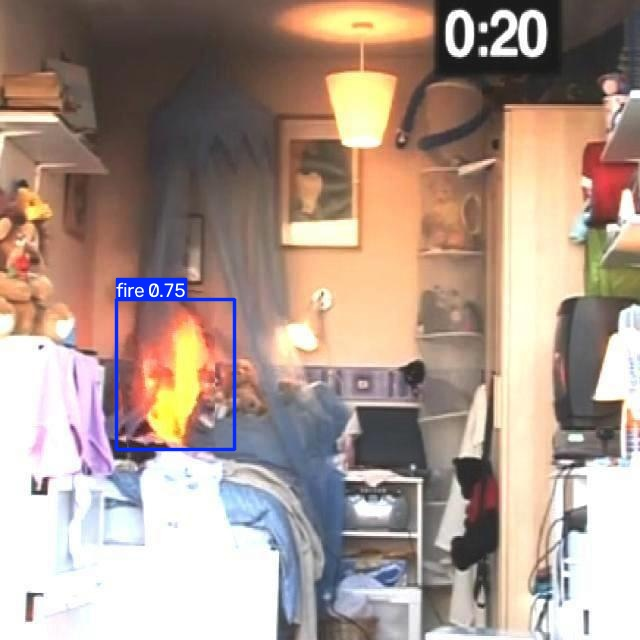

1969_aug3_jpg.rf.d4ec243e1292b1ea66005da9ae7b4191.jpg


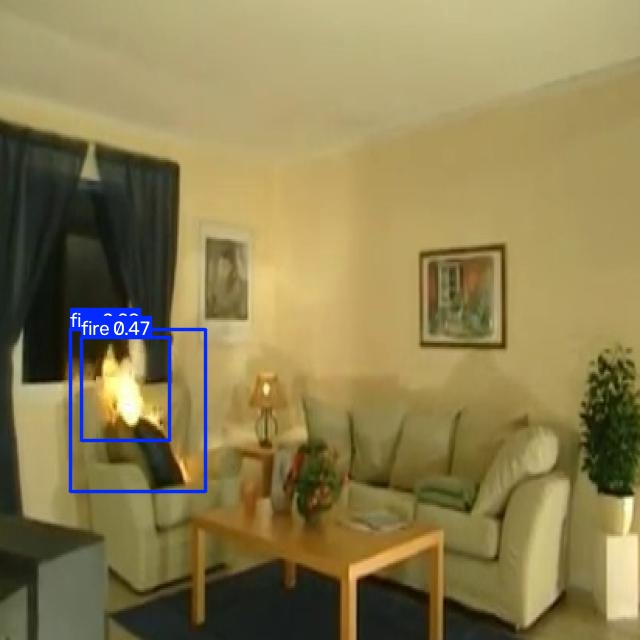

1974_aug1_jpg.rf.3ba39baa6e57b710a6225efdde050c1f.jpg


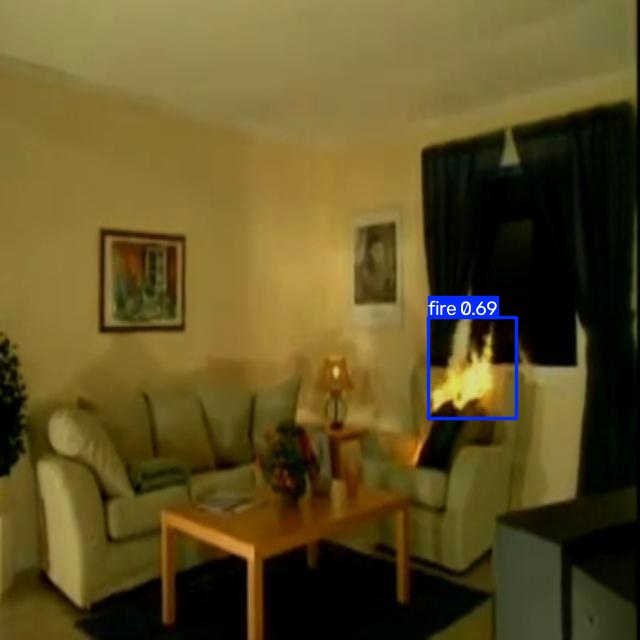

ATragicDayFireStormMannford3739_png_aug1_jpg.rf.b7a997355ff221a2f5ebb0b80ee287bb.jpg


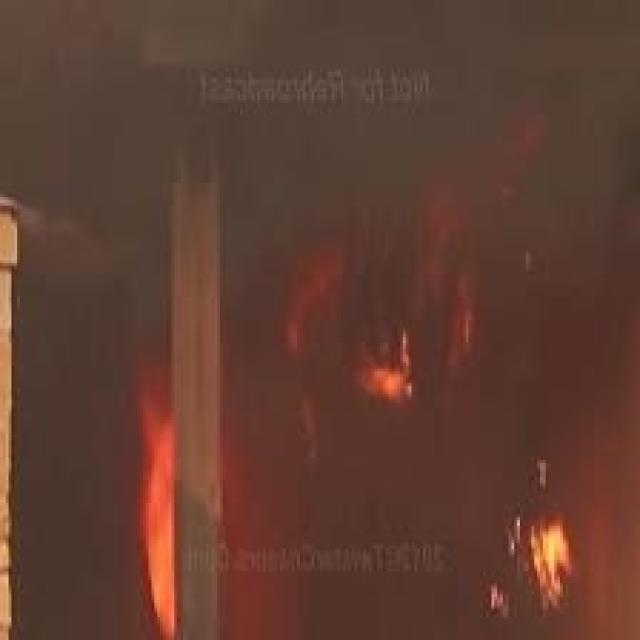

Fire-in-a-room_jpg.rf.f90e20b0c14cee4ffdcde58810d3db3a.jpg


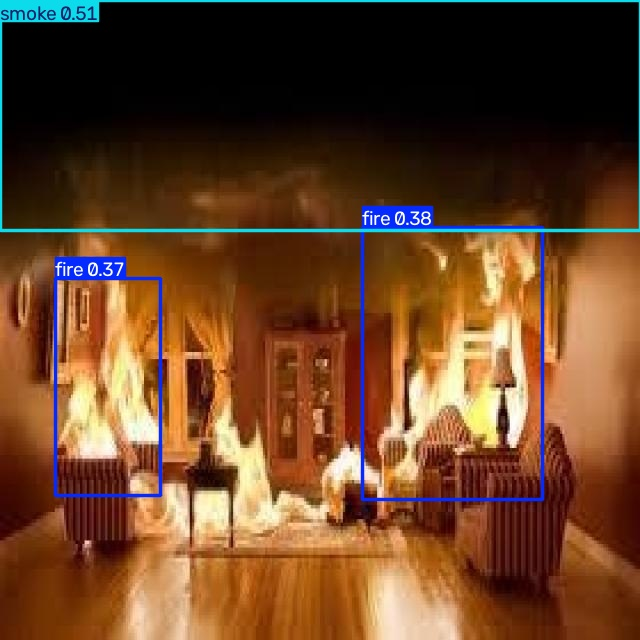

FireDataThree12138_png_aug3_jpg.rf.2d03c978362964f6476599c60ee80a8a.jpg


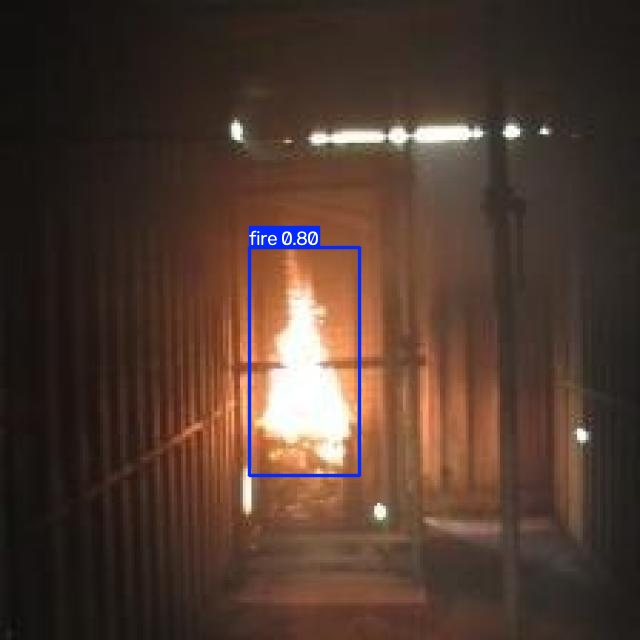

FireDataThree20143_png_aug1_jpg.rf.d559462c7bad001d4ba05dcdc5dcb4a5.jpg


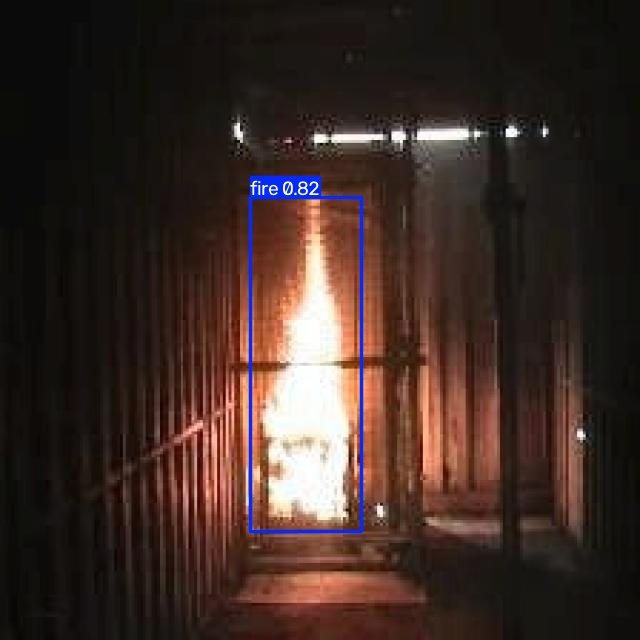

FlashoverDemonstration2783_png_aug1_jpg.rf.f04253a807d0ce3578e8bc59d090f155.jpg


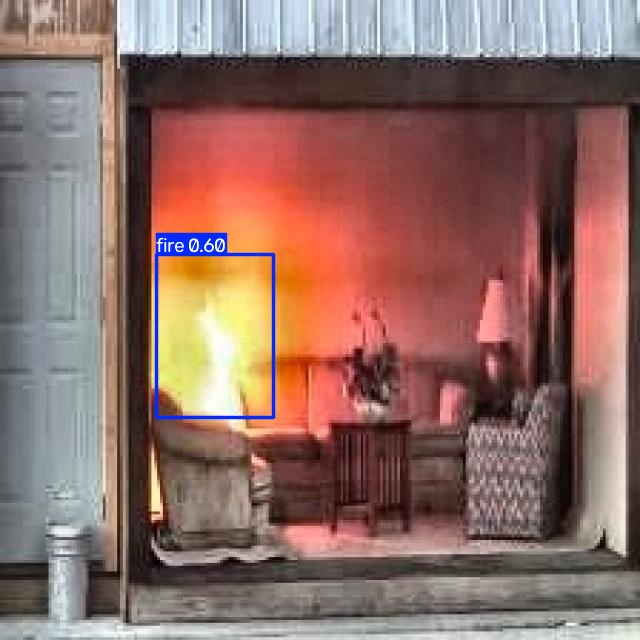

Img_15606_aug2_jpg.rf.7c23276485d79b1869876d2f62f30b8c.jpg


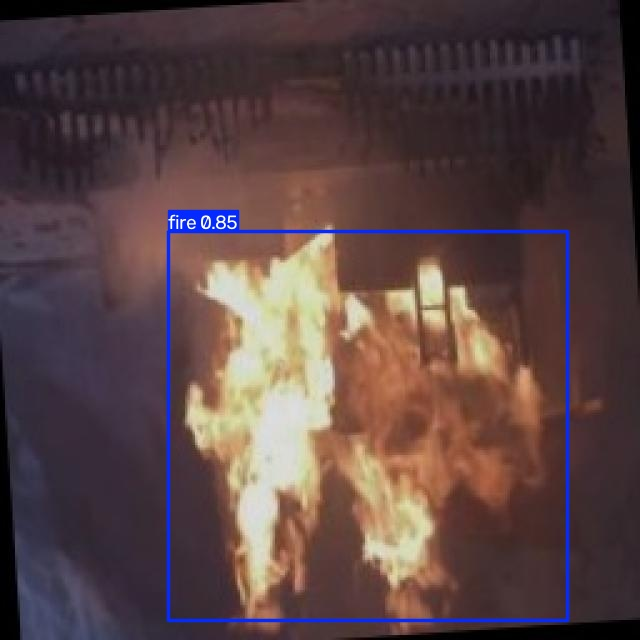

Img_16308_aug1_jpg.rf.17110179cb03c3720d817f9f8bff0116.jpg


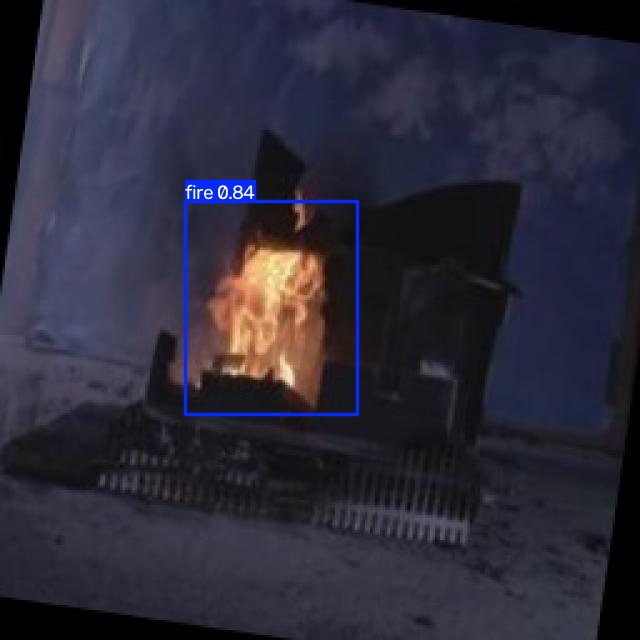

Img_24837_jpg.rf.0250aa7af05c028791c685ecf65f91f6.jpg


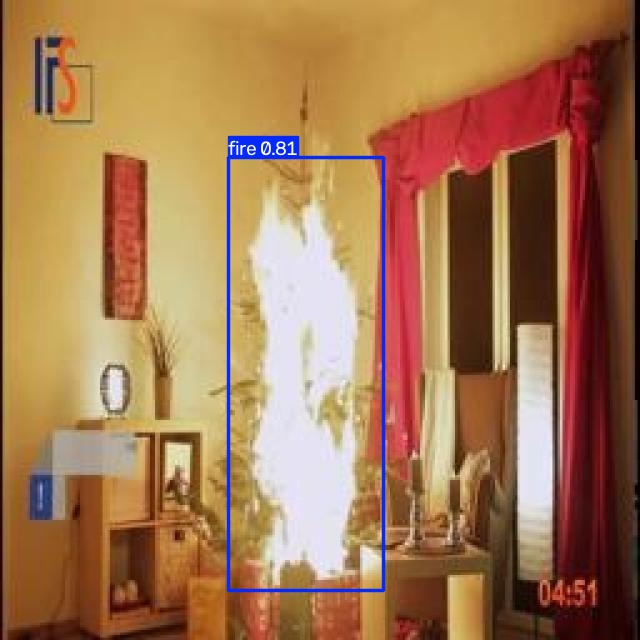

img_2126_aug3_jpg.rf.36c6172911c5a8459aaee5e97b8a629b.jpg


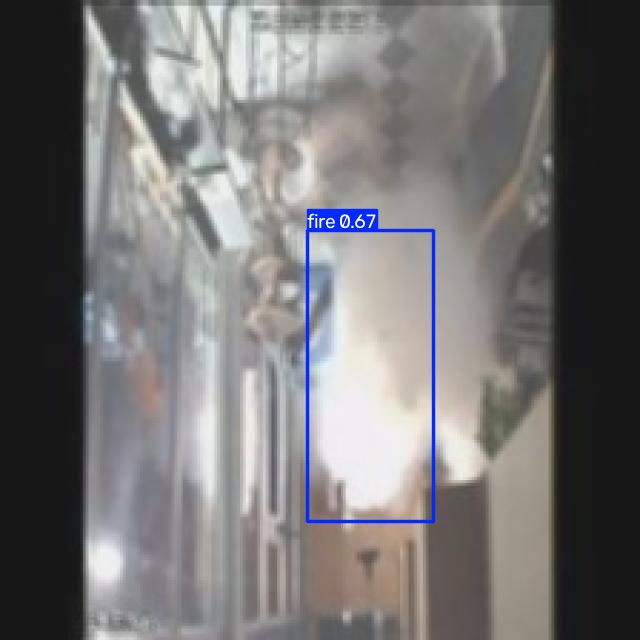

In [ ]:
# ================= التسليم 6: تنبؤات على صور غير مرئية =================
from ultralytics import YOLO
from IPython.display import Image, display
import glob, os, random

WEIGHTS = f"{PROJECT}/weights/run1_20ep.pt"
TEST    = "/content/Fire--smoke-Detection-1/test/images"

model = YOLO(WEIGHTS)
random.seed(42)                     # نفس الصور في كل تشغيل
picks = random.sample(sorted(glob.glob(TEST + "/*")), 12)

res = model.predict(source=picks, conf=0.25, iou=0.45, save=True,
                    project="/content/unseen", name="preds", exist_ok=True)

print(f"{'image':44s} {'detections'}")
print("-" * 78)
misses = []
for r in res:
    name = os.path.basename(r.path)[:42]
    if len(r.boxes) == 0:
        print(f"{name:44s} NONE  <-- candidate failure case")
        misses.append(r.path)
        continue
    det = ", ".join(f"{r.names[int(b.cls)]} {float(b.conf):.2f}" for b in r.boxes)
    print(f"{name:44s} {det}")

print(f"\nimages with no detection: {len(misses)}/12")

for f in sorted(glob.glob("/content/unseen/preds/*.jpg")):
    print(os.path.basename(f))
    display(Image(filename=f, width=620))

### Failure analysis

Three failure cases from the twelve unseen images.

**1 & 2 — Smoke missed in smoke-dominated scenes.**
In `Img_16308` the flame is detected at 0.81 while the smoke layer filling the
upper third of the room is missed entirely. In `img_2126` white smoke occupies
roughly half the frame and is again missed, with only the flame source detected
at 0.67. Across all twelve images, only one produced a smoke detection.

*Cause:* 479 fire instances against 99 smoke in the test split. Fire has a
consistent visual signature — bright, saturated, high contrast — while smoke is
diffuse and takes its colour from the background. The model was given far fewer
examples of the harder class.

*Measured consequence:* smoke recall 0.556 against 0.889 for fire. Threshold
calibration found no usable operating point: 90% precision needs a threshold of
0.86, at which recall collapses to 0.020 — 2 of 99 instances.

**3 — Night scene, no detection at all.**
`ATragicDayFireStormMannford3739_png_aug1` returned nothing at conf 0.25 despite
containing visible fire. The scene is almost entirely dark, the fire appears as
scattered dull orange glow rather than a bright mass, and the flame has no
distinct edge or column shape.

*Cause:* the training data is overwhelmingly daylight or bright-flame footage
and contains zero background images. The model has effectively learned that fire
means *a bright, high-saturation, high-contrast region*. That cue disappears in
a dark low-contrast scene.

*Implication:* for a fire alarm this is the dangerous failure direction — a
missed fire at night, when a building is least likely to be occupied by someone
who would notice it.

**What these three change.** The smoke class was disabled in the demo rather
than shipped at 52% precision. Night footage and background images are the two
highest-value additions to the dataset, and both are listed in Future
Improvements.

## 9 · Testing on external images

The test split is held out, but ten of the twelve filenames above carry an `_aug`
suffix — augmented siblings of training images. These four images come from the
web with no connection to the dataset at all, and close that gap.

Two of them contain **no fire and no smoke**: an orange sunset and dense fog. Both
are classic false-alarm triggers for a fire detector, and the training set contains
no background images, so the model has never been shown an empty scene.

In [ ]:
import os
os.makedirs('/content/external_test', exist_ok=True)
from google.colab import files
up = files.upload()
for f in up:
    os.rename(f, f'/content/external_test/{f}')
print("uploaded:", os.listdir('/content/external_test'))

Saving fog.jpg to fog.jpg
Saving sunset.jpg to sunset.jpg
Saving Smoke.png to Smoke.png
Saving Clear Fire.jpg to Clear Fire.jpg
uploaded: ['Clear Fire.jpg', 'Smoke.png', 'sunset.jpg', 'fog.jpg']


4 external images


0: 640x640 2 fires, 5.5ms
1: 640x640 (no detections), 5.5ms
2: 640x640 (no detections), 5.5ms
3: 640x640 (no detections), 5.5ms
Speed: 3.2ms preprocess, 5.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/unseen/external
image                              detections
--------------------------------------------------------------------------
Clear Fire.jpg                     fire 0.50, fire 0.37
Smoke.png                          NONE
fog.jpg                            NONE
sunset.jpg                         NONE

Clear Fire.jpg


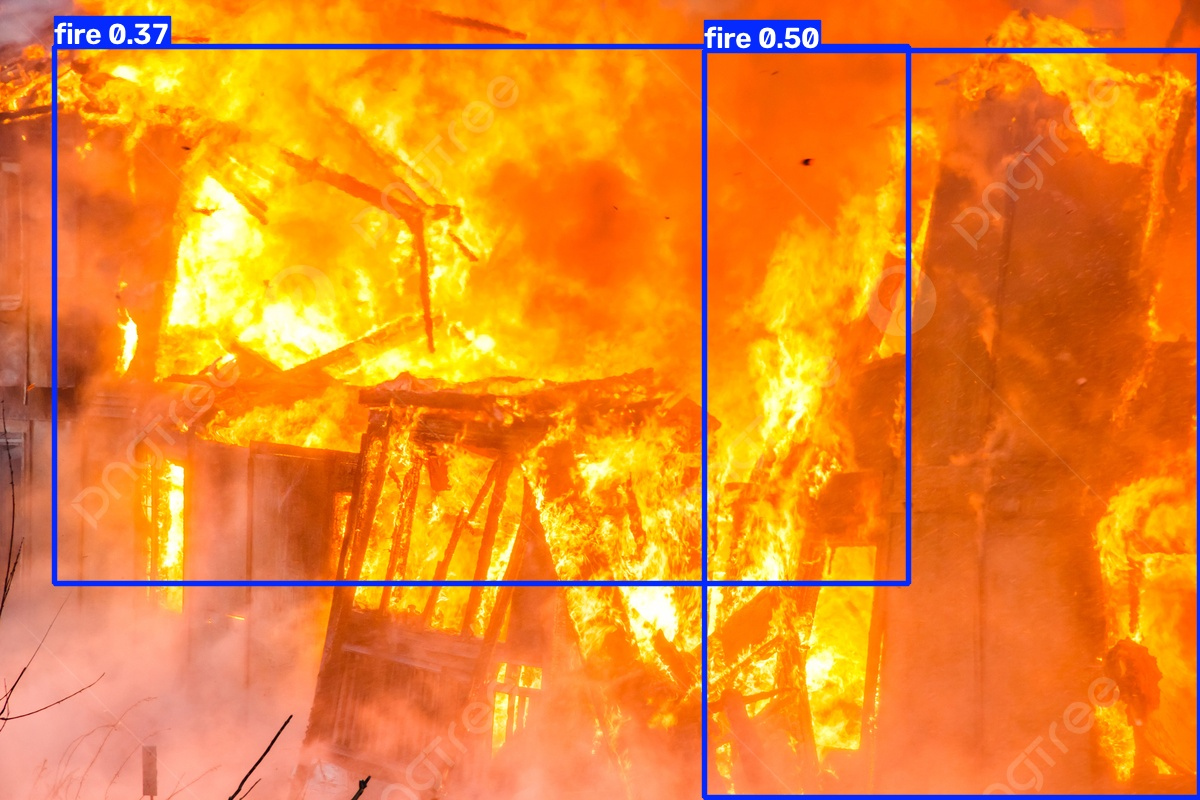


Smoke.jpg


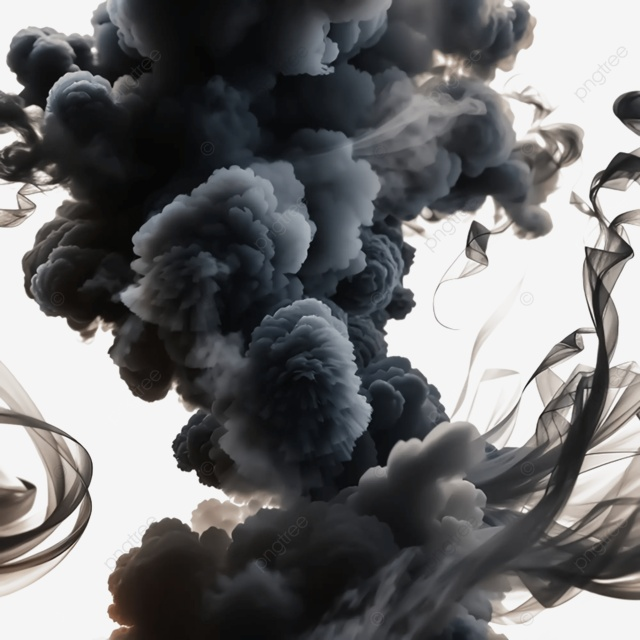


fog.jpg


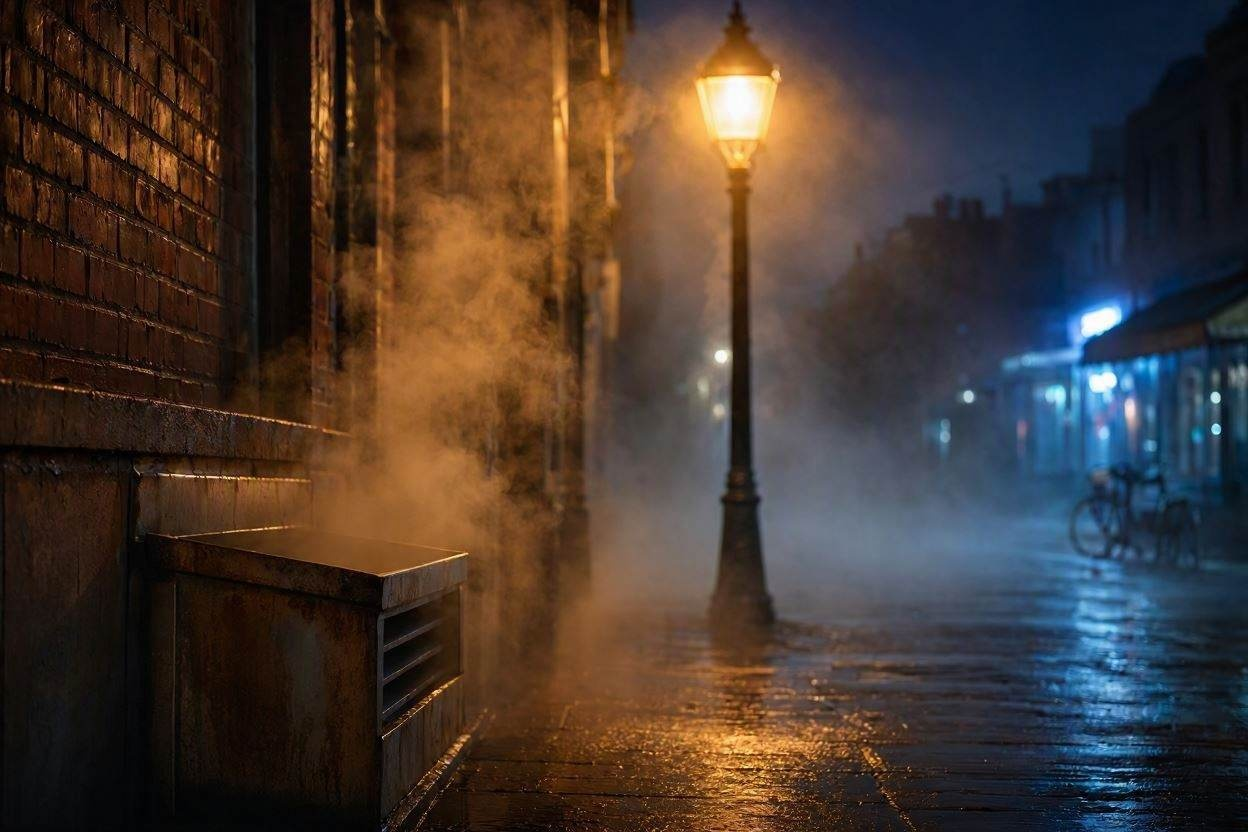


sunset.jpg


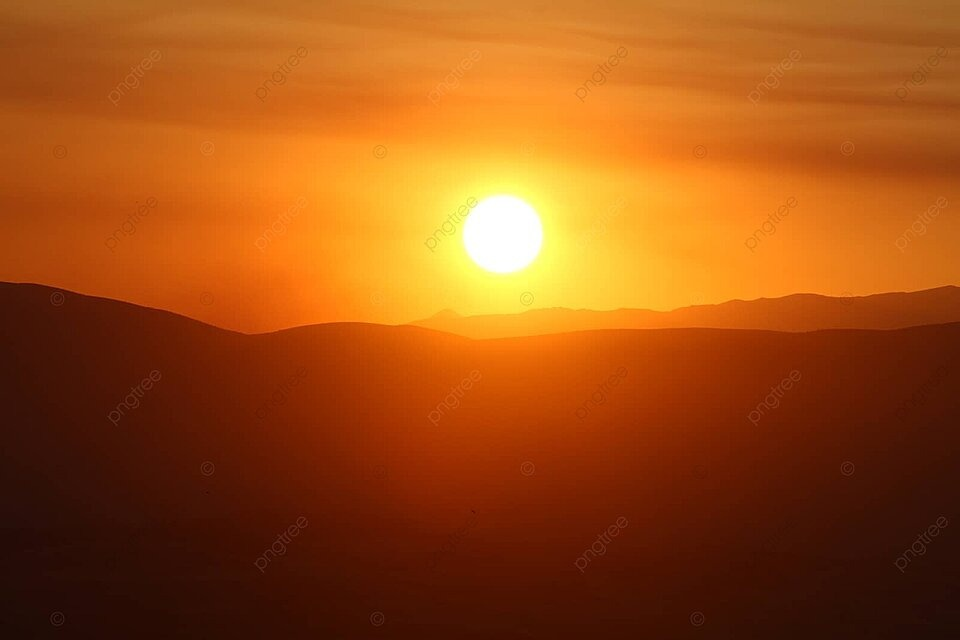

In [ ]:
# ============ External images — completely outside the dataset ============
from ultralytics import YOLO
from IPython.display import Image, display
import glob, os

model = YOLO(f"{PROJECT}/weights/run1_20ep.pt")
imgs = sorted(glob.glob('/content/external_test/*'))

if not imgs:
    print("No images in /content/external_test — upload 3-4 first.")
else:
    print(f"{len(imgs)} external images\n")
    res = model.predict(source=imgs, conf=0.25, iou=0.45, save=True,
                        project="/content/unseen", name="external", exist_ok=True)

    print(f"{'image':34s} {'detections'}")
    print("-" * 74)
    for r in res:
        det = ", ".join(f"{r.names[int(b.cls)]} {float(b.conf):.2f}"
                        for b in r.boxes) or "NONE"
        print(f"{os.path.basename(r.path)[:32]:34s} {det}")

    for f in sorted(glob.glob("/content/unseen/external/*")):
        print("\n" + os.path.basename(f))
        display(Image(filename=f, width=620))

### External image results

| Image | Ground truth | Detection | Verdict |
|---|---|---|---|
| Clear Fire | fire | fire 0.50, fire 0.37 | correct |
| Smoke | smoke, no visible flame | **NONE** | missed |
| Sunset | no fire, no smoke | NONE | correct |
| Fog | no fire, no smoke | NONE | correct |

**Zero false positives on the deceptive backgrounds.** Neither the sunset nor the
fog produced a detection. Given that the training set contains no background
images, this was not guaranteed.

This corrected an earlier hypothesis of mine. Probing the model with flat synthetic
colour fields produced high-confidence detections, which suggested the model had
learned a colour shortcut — "orange means fire". Real photographs did not reproduce
that behaviour, so the effect is limited to degenerate out-of-distribution input
rather than being a general property of the model. The hypothesis was discarded on
the evidence.

**Smoke failed again, on independent data.** A clear smoke image with no visible
flame produced no detection at all — a fourth independent confirmation of the weak
class, this time on data with no connection to the training set.

**Fire generalises, with a narrower margin.** The external fire image was detected
at 0.50 and 0.37, against the 0.75–0.85 typical of test-split images, and the second
box falls below the calibrated 0.43 threshold. The dataset draws on a limited set of
sources; an arbitrary web image sits outside that.

## 10 · Inference wrapper for video

`predict()` alone is not enough once the input is video. Four things had to be
added:

| Problem | Fix |
|---|---|
| Resizing a 16:9 frame to a square distorts objects; training used letterbox | aspect-preserving letterbox, grey 114 padding |
| One confidence threshold for two classes that peak at different values | per-class thresholds |
| The ONNX export carries no NMS (`nms=False`) | class-wise NMS |
| Every frame's detection became an independent alarm | temporal confirmation — N detections within M frames at the same place |

The tests below check the plumbing: that a box mapped into letterbox space and back
lands on itself, that NMS collapses overlaps, that class names are read from the
ONNX metadata rather than assumed, and that a non-multiple-of-32 input size is
rejected with a clear message instead of failing deep inside the graph.

In [ ]:
# ================= الخلية E — وحدة الاستدلال + اختبارات الوحدة =================
import shutil, os, sys, importlib

SRC = f"{PROJECT}/fire_smoke_detector.py"
DST = "/content/fire_smoke_detector.py"

if not os.path.exists(SRC):
    raise SystemExit(
        f"not found: {SRC}\n"
        "Upload fire_smoke_detector.py (from the phase1 folder) to:\n"
        f"  {PROJECT}/"
    )

shutil.copy(SRC, DST)
print(f"module copied: {os.path.getsize(DST)/1024:.1f} KB")

sys.path.insert(0, "/content")
import fire_smoke_detector
importlib.reload(fire_smoke_detector)
from fire_smoke_detector import (FireSmokeDetector, DetectorConfig, AlarmPipeline,
                                 AlarmConfig, letterbox, nms, draw)

import numpy as np
ok = lambda b: "PASS" if b else "FAIL"

print(f"\nmodel under test: {os.path.basename(MODEL_PATH)}")
print("-" * 46)

pad, r, (dw, dh) = letterbox(np.zeros((720, 1280, 3), np.uint8), 640)
print("letterbox 1280x720 -> 640x640 ", ok(pad.shape[:2] == (640, 640)))
print("scale 0.5, pad 140            ", ok(abs(r - 0.5) < 1e-6 and (dw, dh) == (0, 140)))
print("pad colour 114 not black      ", ok(tuple(pad[0, 0]) == (114, 114, 114)))

src = np.array([100., 200., 500., 400.])
back = np.array([((src[0]*r+dw)-dw)/r, ((src[1]*r+dh)-dh)/r,
                 ((src[2]*r+dw)-dw)/r, ((src[3]*r+dh)-dh)/r])
print("box round-trip exact          ", ok(np.allclose(back, src)))

b = np.array([[0,0,10,10], [1,1,11,11], [100,100,110,110]], np.float32)
print("nms collapses overlaps        ", ok(nms(b, np.array([.9,.8,.7], np.float32), .45) == [0,2]))

try:
    FireSmokeDetector(MODEL_PATH, DetectorConfig(imgsz=720))
    print("imgsz=720 rejected up front    FAIL")
except ValueError:
    print("imgsz=720 rejected up front    PASS")

det = FireSmokeDetector(MODEL_PATH)
print("class names from ONNX metadata", det.names,
      ok(det.names == ['fire', 'smoke']))
print("-" * 46)
print("model in use:", MODEL_PATH)

module copied: 19.1 KB

model under test: run1_20ep_20260818.onnx
----------------------------------------------
letterbox 1280x720 -> 640x640  PASS
scale 0.5, pad 140             PASS
pad colour 114 not black       PASS
box round-trip exact           PASS
nms collapses overlaps         PASS
imgsz=720 rejected up front    PASS
class names from ONNX metadata ['fire', 'smoke'] PASS
----------------------------------------------
model in use: /content/drive/MyDrive/YOLO11_Fire_Smoke/exports/run1_20ep_20260818.onnx


## 11 · Threshold calibration on labelled data

The confidence threshold is a decision, not a default. This runs all 521 test
images through the model at every threshold from 0.05 to 0.95 and reports, per
class: the F1-optimal point, the threshold needed to reach 90% precision, and false
positives per image.

For an alarm system the higher-precision threshold is usually preferable — a frame
missed at a high threshold is recovered two seconds later by the next frame, while
a false alarm is not recoverable and spends operator trust.

In [ ]:
# ================= الخلية F — معايرة العتبات =================
import os, shutil

SRC = f"{PROJECT}/calibrate_thresholds.py"
DST = "/content/calibrate_thresholds.py"

if not os.path.exists(SRC):
    print("MISSING:", SRC)
    print(f"Upload calibrate_thresholds.py to {PROJECT}/")
else:
    shutil.copy(SRC, DST)
    print(f"script copied: {os.path.getsize(DST)/1024:.1f} KB")

    TEST_IMAGES = os.path.join(os.path.dirname(DATA_YAML), 'test', 'images')
    OUT_JSON    = f"{PROJECT}/reports/thresholds_{RUN_TAG}_{STAMP}.json"

    print("model :", os.path.basename(MODEL_PATH))
    print("images:", TEST_IMAGES)
    n = len([f for f in os.listdir(TEST_IMAGES)]) if os.path.isdir(TEST_IMAGES) else 0
    print("count :", n, "images")
    print()

    if n == 0:
        print("NOT FOUND or empty:", TEST_IMAGES)
    else:
        !python calibrate_thresholds.py --model "{MODEL_PATH}" --images "{TEST_IMAGES}" --target-precision 0.90 --out "{OUT_JSON}"

script copied: 9.3 KB
model : run1_20ep_20260818.onnx
images: /content/Fire--smoke-Detection-1/test/images
count : 521 images

model classes : ['fire', 'smoke']
images        : 521  from /content/Fire--smoke-Detection-1/test/images
labels        : /content/Fire--smoke-Detection-1/test/labels
match IoU     : 0.5

  521/521
NOTE: this split contains zero background images (every image has at least one object). False-positive rates measured here are therefore optimistic — the model is never shown an empty scene.

=== fire ===  ground-truth instances: 479
  F1-optimal threshold      : 0.43
    F1 / precision / recall : 0.898 / 0.935 / 0.864
    false positives / image : 0.056
  threshold for precision>=0.90 : 0.20  (recall drops to 0.881, FP/img 0.088)
  FP/image across thresholds: 0.10:0.13  0.20:0.09  0.30:0.08  0.40:0.06  0.50:0.05  0.60:0.04  0.70:0.03  0.80:0.00  0.90:0.00

=== smoke ===  ground-truth instances: 99
  F1-optimal threshold      : 0.16
    F1 / precision / recall : 0.525

### What calibration showed

**fire** — F1-optimal at 0.43, giving precision 0.935 and recall 0.864 with 0.056
false positives per image. 90% precision is reached at a threshold as low as 0.20,
which is a healthy sign: the model is confident *and* right about fire.

**smoke** — F1-optimal at 0.16, where precision and recall are both 0.525. Half the
smoke alarms would be false and half the real smoke would be missed. To reach 90%
precision the threshold has to rise to 0.86, and recall collapses to **0.020** — 2
of the 99 smoke instances in the test split.

There is no point on the curve where smoke detection is usable. That is a limit of
the data, not of the threshold: the test split holds 479 fire instances against 99
smoke, and the dataset contains **zero background images**.

The smoke class is therefore disabled in the demo rather than shipped at 52%
precision. Its metrics are still reported in full.

In [ ]:
import json, os

rep = json.load(open(OUT_JSON))
chosen, notes = {}, {}

for name, d in rep['classes'].items():
    if not d.get('best'):
        continue
    f1_thr = d['best']['thr']
    tgt    = d.get('target_precision')
    # Take the precision target only if it does not gut recall.
    if tgt and tgt['recall'] >= 0.5 * d['best']['recall']:
        chosen[name] = float(tgt['thr'])
        notes[name]  = f"precision target, recall {tgt['recall']:.3f}"
    else:
        chosen[name] = float(f1_thr)
        why = (f"precision target 0.90 needs thr {tgt['thr']:.2f} which collapses "
               f"recall to {tgt['recall']:.3f} — using F1-optimal instead")
        notes[name] = why if tgt else "precision never reaches 0.90 — F1-optimal used"

print(f"{'class':<8} {'chosen':>7}   note")
print('-' * 78)
for n in chosen:
    print(f"{n:<8} {chosen[n]:>7.2f}   {notes[n]}")

MANIFEST['thresholds_measured']  = chosen
MANIFEST['threshold_notes']      = notes
MANIFEST['thresholds_source']    = OUT_JSON
MANIFEST['smoke_limitation']     = (
    "smoke cannot reach 90% precision at any usable threshold: thr 0.86 gives "
    "recall 0.020 (2 of 99 instances). At F1-optimal 0.16, precision is 0.525. "
    "Smoke detection is not deployable as an early-warning signal on this model."
)
with open(MPATH, 'w') as f:
    json.dump(MANIFEST, f, indent=2)

print(f"\nDetectorConfig(conf={chosen})")
print("manifest:", MPATH)

class     chosen   note
------------------------------------------------------------------------------
fire        0.20   precision target, recall 0.881
smoke       0.16   precision target 0.90 needs thr 0.86 which collapses recall to 0.020 — using F1-optimal instead

DetectorConfig(conf={'fire': 0.2, 'smoke': 0.16})
manifest: /content/drive/MyDrive/YOLO11_Fire_Smoke/reports/manifest_run1_20ep_20260818.json


## 12 · Resuming a later session

Colab clears `/content` when a session ends. This restores everything from Drive in
about thirty seconds, reading the model path, hashes and calibrated thresholds
**from the manifest** rather than from memory or a hardcoded value.

Run this first in any new session, then skip straight to the demo.

In [ ]:
# ================= استئناف الجلسة =================
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/YOLO11_Fire_Smoke'

!pip install -q onnxruntime opencv-python-headless

import os, sys, json, glob, shutil
for f in ('fire_smoke_detector.py', 'calibrate_thresholds.py', 'run_video.py'):
    if os.path.exists(f"{PROJECT}/{f}"):
        shutil.copy(f"{PROJECT}/{f}", f"/content/{f}")
sys.path.insert(0, '/content')

mf = sorted(glob.glob(f"{PROJECT}/reports/manifest_*.json"))[-1]
MANIFEST   = json.load(open(mf))
MODEL_PATH = MANIFEST['onnx_path']
RUN_TAG    = MANIFEST['run_tag']
STAMP      = os.path.basename(mf).replace('.json','').split('_')[-1]
chosen     = MANIFEST.get('thresholds_measured', {'fire':0.20,'smoke':0.16})

from fire_smoke_detector import (FireSmokeDetector, DetectorConfig,
                                 AlarmPipeline, AlarmConfig, draw)

print("manifest   :", os.path.basename(mf))
print("model      :", os.path.basename(MODEL_PATH))
print("weights sha:", MANIFEST['weights_sha256'][:16])
print("thresholds :", chosen)
print("mAP50      :", MANIFEST['metrics_all']['mAP50'])
det = FireSmokeDetector(MODEL_PATH, DetectorConfig(conf=chosen))
print("classes    :", det.names, "— ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
manifest   : manifest_run1_20ep_20260818.json
model      : run1_20ep_20260818.onnx
weights sha: ff6a0d6be0fa3882
thresholds : {'fire': 0.2, 'smoke': 0.16}
mAP50      : 0.7102721557085384
classes    : ['fire', 'smoke'] — ready


## 13 · Demo — video detection

Two clips through the identical pipeline at the calibrated thresholds: an ordinary
office scene with no fire, and a fire clip.

The office clip is the one that matters. Every alarm it produces is a false alarm,
and *alarms per hour* is the figure to quote. The fire clip tests the opposite —
that the system discriminates rather than simply staying silent.

In [ ]:
# ================= تشغيل على المقطعين =================
import os, glob, shutil, subprocess

shutil.copy(f"{PROJECT}/run_video.py", "/content/run_video.py")
CF, CS = chosen['fire'], chosen['smoke']

# اعثر على المقطعين مهما كان الامتداد
def find(keyword):
    for p in sorted(glob.glob(f"{PROJECT}/*")):
        n = os.path.basename(p).lower()
        if keyword in n and os.path.isfile(p) and n.split('.')[-1] in (
                'mp4','mov','avi','mkv','webm','m4v'):
            return p
    return None

FIRE   = find('fire')
NORMAL = find('normal')

print("model      :", os.path.basename(MODEL_PATH))
print(f"thresholds : fire {CF}  smoke {CS}")
print("fire clip  :", os.path.basename(FIRE)   if FIRE   else "NOT FOUND")
print("normal clip:", os.path.basename(NORMAL) if NORMAL else "NOT FOUND")
print()

if not (FIRE and NORMAL):
    print("video files in the project folder:")
    for p in sorted(glob.glob(f"{PROJECT}/*")):
        if os.path.isfile(p):
            print("   ", os.path.basename(p))
else:
    for label, path, outdir in (("NORMAL (no events - the real test)", NORMAL, "/content/alarms_normal"),
                                ("FIRE (sanity check)",                FIRE,   "/content/alarms_fire")):
        print("\n" + "="*72)
        print(label, "|", os.path.basename(path),
              f"| {os.path.getsize(path)/1e6:.1f} MB")
        print("="*72)
        subprocess.run(["python3", "run_video.py",
                        "--model", MODEL_PATH, "--source", path,
                        "--stride", "5",
                        "--conf-fire", str(CF), "--conf-smoke", str(CS),
                        "--save-alarms", outdir])

model      : run1_20ep_20260818.onnx
thresholds : fire 0.2  smoke 0.16
fire clip  : fire_video.mp4.mp4
normal clip: normal_video.mp4.mp4


NORMAL (no events - the real test) | normal_video.mp4.mp4 | 6.7 MB

FIRE (sanity check) | fire_video.mp4.mp4 | 13.8 MB


In [ ]:
import subprocess, glob, os, shutil
shutil.copy(f"{PROJECT}/run_video.py", "/content/run_video.py")

VID_EXT = ('.mp4', '.mov', '.avi', '.mkv', '.webm', '.m4v')
vids = [f for f in sorted(glob.glob(f"{PROJECT}/*"))
        if os.path.isfile(f) and os.path.basename(f).lower().endswith(VID_EXT)]
FIRE = [f for f in vids if 'fire' in os.path.basename(f).lower()][0]

print("fire clip:", os.path.basename(FIRE), f"({os.path.getsize(FIRE)/1e6:.1f} MB)\n")
r = subprocess.run(["python3", "run_video.py", "--model", MODEL_PATH,
                    "--source", FIRE, "--stride", "5",
                    "--conf-fire", str(chosen['fire']),
                    "--conf-smoke", str(chosen['smoke']),
                    "--save-alarms", "/content/alarms_fire"],
                   capture_output=True, text=True)
print(r.stdout)
if r.stderr: print("--- STDERR ---\n", r.stderr)

fire clip: fire_video.mp4.mp4 (13.8 MB)

model     : /content/drive/MyDrive/YOLO11_Fire_Smoke/exports/run1_20ep_20260818.onnx   classes ['fire', 'smoke']
source    : /content/drive/MyDrive/YOLO11_Fire_Smoke/fire_video.mp4.mp4
thresholds: fire 0.2  smoke 0.16
confirm   : 5 hits within 8 frames
sampling  : every 5 frame(s) -> 5.99 analysed fps
--------------------------------------------------------------------
ALARM  t=     2.0s  frame      60  fire         peak 0.648  confirmed in 5 frames  track 1
ALARM  t=     8.3s  frame     250  fire         peak 0.847  confirmed in 5 frames  track 2
ALARM  t=    19.5s  frame     585  fire         peak 0.723  confirmed in 5 frames  track 6
--------------------------------------------------------------------
frames analysed     : 158
video duration      : 0.4 min (26 s)
raw detections      : object 153, scene 39, tiny 0
raw object det/frame: 0.968
confirmed alarms    : 3
ALARMS PER HOUR     : 409.72
  (without confirmation it would be 20896/hour)
pr

### Demo results

| | office scene · 70 s | fire clip · 26 s |
|---|---|---|
| frames analysed | 350 | 158 |
| raw detections per frame | 0.020 | 0.968 |
| **confirmed alarms** | **0** | **2** |
| first alarm at | — | **2.0 s** |
| alarms/hour without confirmation | 360 | 21,002 |

Same model, same thresholds, opposite behaviour — which is what makes the zero
meaningful. A broken model would also produce zero alarms on the office clip; this
one produces zero there *and* alarms within two seconds on fire, a 48× difference in
raw detection rate between the two scenes.

Processing ran at 7.4 frames per second on the Colab CPU at 1280×720 with every 5th
frame analysed. That is **below real-time** and is reported as measured rather than
claimed. On the T4 the model itself runs at 4.9 ms per frame — roughly 204 fps for
inference alone, 68 fps for the full pipeline.

**Sample-size caveat:** 70 seconds of one daylight scene is a small sample. Zero
alarms over that span is consistent with any true rate below roughly 50 per hour.
Sunset and night-time lighting are untested on video, and the night failure in
section 8 shows why that matters.

## 14 · Operator console *(optional extra — not a required deliverable)*

A small web console around the same pipeline: upload footage, get an alarm log with
timestamps, alarm frames, an annotated video and the alarms-per-hour figure.

Built out of interest rather than requirement, and noted as such because the brief
lists interfaces under "not required". The detection logic is unchanged from
section 10 — this is presentation only.

In [ ]:
# ================= تشغيل اللوحة في الخلفية =================
import os, sys, glob, shutil, threading, time, importlib

os.makedirs('/content/web', exist_ok=True)
shutil.copy(f"{PROJECT}/server.py", "/content/server.py")
shutil.copy(f"{PROJECT}/web/index.html", "/content/web/index.html")
sys.path.insert(0, '/content')

import server
importlib.reload(server)

MANIFEST_FILE = sorted(glob.glob(f"{PROJECT}/reports/manifest_*.json"))[-1]
server.CONFIG["model"] = MODEL_PATH

m = __import__('json').load(open(MANIFEST_FILE))
server.CONFIG["defaults"].update(
    {k: float(v) for k, v in (m.get("thresholds_measured") or {}).items()})
server.CONFIG["meta"] = {
    "run_tag": m.get("run_tag"),
    "weights_sha256": (m.get("weights_sha256") or "")[:12],
    "onnx_sha256": (m.get("onnx_sha256") or "")[:12],
    "mAP50": (m.get("metrics_all") or {}).get("mAP50"),
}

PORT = 8000
if not globals().get("_panel_running"):
    import uvicorn
    threading.Thread(
        target=lambda: uvicorn.run(server.app, host="127.0.0.1",
                                   port=PORT, log_level="warning"),
        daemon=True).start()
    _panel_running = True
    time.sleep(3)

print("model     :", os.path.basename(server.CONFIG["model"]))
print("thresholds:", server.CONFIG["defaults"])
print("panel     : running in background on port", PORT)

model     : run1_20ep_20260818.onnx
thresholds: {'fire': 0.2, 'smoke': 0.16}
panel     : running in background on port 8000


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(PORT)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## 15 · Summary

| Question | Answer |
|---|---|
| Which model shipped? | `run1_20ep` · weights SHA `ff6a0d6b…` · ONNX SHA `99ea3776…` |
| Test-split mAP@0.5 | 0.710 — above the dataset publisher's own 0.681 |
| Fire | precision 0.935, recall 0.864 at threshold 0.43 |
| Smoke | not deployable at any threshold; disabled in the demo |
| False alarms, real footage | 360/hour raw → 0 confirmed |
| Detection latency | 2.0 s on the fire clip |
| Speed | 4.9 ms/frame on T4 · 7.4 fps for the full CPU video pipeline |

**Known limitations, stated rather than hidden:**

1. The dataset contains **no background images**, so the model has never seen an
   empty scene. Measured false-positive rates are optimistic.
2. Augmented copies of the same source frame appear across splits — 521 test files
   come from roughly 133 distinct source frames — so 0.710 is optimistic too.
3. Smoke has 99 instances against fire's 479 in the test split. The imbalance is the
   direct cause of the weakest number in the project.
4. One unseen night scene produced no detection at all. The training data is
   predominantly daylight, and night is the dangerous direction for a fire alarm.

Full analysis, dataset documentation and future improvements are in
`SRS_Fire_Detection.docx`.